# ⚙️ Ames Housing — Feature Engineering

**Project:** Real Estate Price Analysis — Ames, Iowa  
**Author:** A.K  
**Phase:** 4 of 7 — Data Preparation continued (CRISP-DM)

## What this notebook does
Transforms the cleaned dataset into model-ready inputs:
1. Create new features from existing columns (domain knowledge)
2. Encode categorical variables (label + one-hot encoding)
3. Transform the target variable (log scale)
4. Scale numeric features
5. Save the final feature matrix

## Why this phase exists
Machine learning models speak only one language: numbers.
Every categorical column must become a number.
Every skewed distribution must be corrected.
Every feature must live on a comparable scale.

### A. Importing and Loading Cleaned Dataset

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

# Load the CLEANED file — never go back to the raw data:

df = pd.read_csv(r'C:\Users\A.K\DATA_SCIENCE_WORKSPACE\kaggle_projects\project_4_amesHousing\Real Estate-AmesHousing-Analysis\00 Data\Processed Data\AmesHousing_cleaned.csv')
print(f"Loaded cleaned data: {df.shape}")
df_feat = df.copy()
print("Working copy created ✓")

Loaded cleaned data: (2927, 82)
Working copy created ✓


## Part 1 — Create New Features

New features built from domain knowledge consistently outperform raw columns
because they capture the *meaning* behind the numbers, not just the numbers themselves.

We create 5 new features:
- `House Age` — how old was the house when sold?
- `Remod Age` — how recently was it remodeled?
- `Total SF` — true total living space across all floors
- `Total Baths` — all bathrooms combined into one signal
- `Has Pool`, `Has Garage`, `Has Fireplace` — binary amenity flags

### B. Features creation

In [30]:
#1. Age features:

df_feat['House Age']  = df_feat['Yr Sold'].astype(int) - df_feat['Year Built']
df_feat['Remod Age']  = df_feat['Yr Sold'].astype(int) - df_feat['Year Remod/Add']

In [31]:
# Safely convert Yr Sold back to int for arithmetic
# (it was converted to string for encoding purposes):

yr_sold_int = df_feat['Yr Sold'].astype(str).str.strip().astype(int)

df_feat['House Age']  = yr_sold_int - df_feat['Year Built']
df_feat['Remod Age']  = yr_sold_int - df_feat['Year Remod/Add']

# Clip negatives — a handful of data entry errors show remodel year > sold year
df_feat['House Age']  = df_feat['House Age'].clip(lower=0)
df_feat['Remod Age']  = df_feat['Remod Age'].clip(lower=0)

print("Age features:")
print(df_feat[['House Age', 'Remod Age']].isnull().sum())

Age features:
House Age    0
Remod Age    0
dtype: int64


In [32]:
#2. Total living space
# Gr Liv Area is above-ground only; this adds basement finished space:

df_feat['Total SF'] = (df_feat['Gr Liv Area'] +
                       df_feat['BsmtFin SF 1'] +
                       df_feat['BsmtFin SF 2'])

In [33]:
#3. Total bathrooms
# Half baths count as 0.5 — a standard real estate convention:

df_feat['Total Baths'] = (df_feat['Full Bath'] +
                           df_feat['Half Bath'] * 0.5 +
                           df_feat['Bsmt Full Bath'] +
                           df_feat['Bsmt Half Bath'] * 0.5)

In [34]:
#4. Binary amenity flags:

df_feat['Has Pool']      = (df_feat['Pool Area'] > 0).astype(int)
df_feat['Has Garage']    = (df_feat['Garage Area'] > 0).astype(int)
df_feat['Has Fireplace'] = (df_feat['Fireplaces'] > 0).astype(int)
df_feat['Has Remodel']   = (df_feat['Year Remod/Add'] != df_feat['Year Built']).astype(int)

new_features = ['House Age', 'Remod Age', 'Total SF',
                'Total Baths', 'Has Pool', 'Has Garage',
                'Has Fireplace', 'Has Remodel']

In [35]:
#Checking the new features:

print("New features created:")
print(df_feat[new_features].describe().round(2))

New features created:
       House Age  Remod Age  Total SF  Total Baths  Has Pool  Has Garage  \
count    2927.00    2927.00   2927.00      2927.00   2927.00     2927.00   
mean       36.47      23.55   1984.58         2.22      0.00        0.95   
std        30.28      20.85    722.76         0.80      0.06        0.23   
min         0.00       0.00    334.00         1.00      0.00        0.00   
25%         7.00       4.00   1491.00         1.50      0.00        1.00   
50%        34.00      15.00   1850.00         2.00      0.00        1.00   
75%        54.00      43.00   2377.00         2.50      0.00        1.00   
max       136.00      60.00   6572.00         7.00      1.00        1.00   

       Has Fireplace  Has Remodel  
count        2927.00      2927.00  
mean            0.51         0.46  
std             0.50         0.50  
min             0.00         0.00  
25%             0.00         0.00  
50%             1.00         0.00  
75%             1.00         1.00  
max  

### C. Verify New Features with Plots

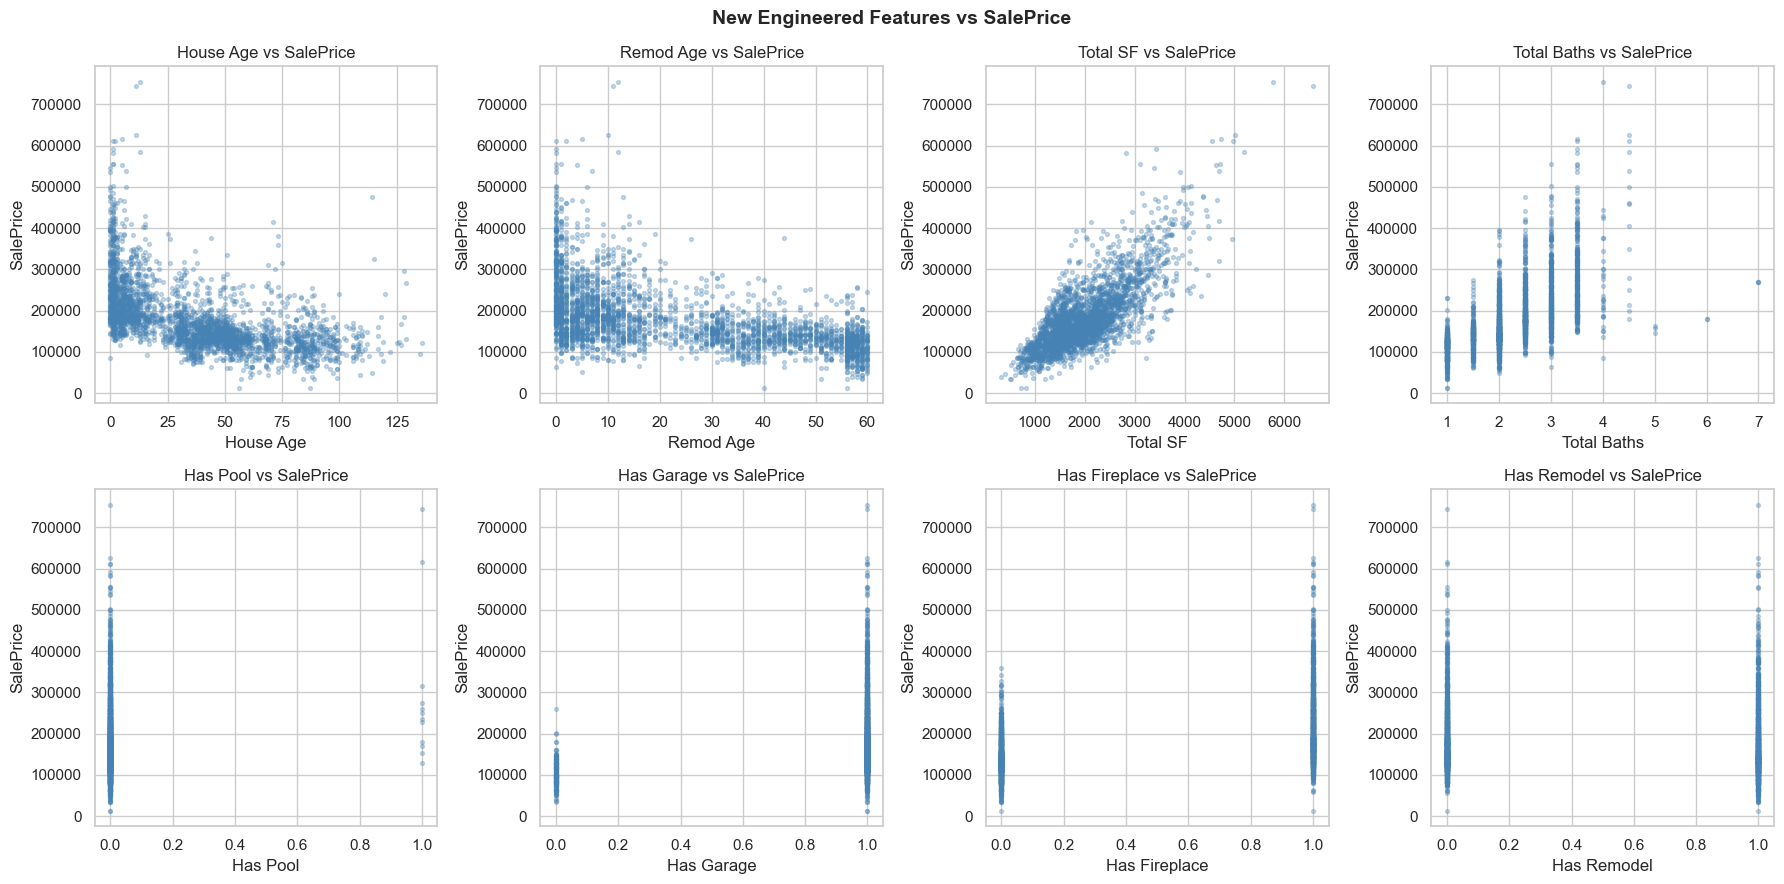

In [36]:
# Visualizing the new features:

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, feat in enumerate(new_features):
    axes[i].scatter(df_feat[feat], df_feat['SalePrice'],
                    alpha=0.3, color='steelblue', s=8)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('SalePrice')
    axes[i].set_title(f'{feat} vs SalePrice')

plt.suptitle('New Engineered Features vs SalePrice', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\03 Feature Engineering\\Report\\engineered_features.png', dpi=150)
plt.show()

## Part 2 — Encode Categorical Variables

Models cannot process text. We use two encoding strategies:

**1. Ordinal encoding** — for quality/condition columns that have a natural order  
(Poor < Fair < Typical < Good < Excellent)  
→ Map to numbers 0, 1, 2, 3, 4 — the order *means something*

**2. One-hot encoding** — for nominal columns with no natural order  
(Neighborhood, House Style, Sale Type)  
→ Create a binary column for each category

### D. Ordinal Encoding

In [37]:
quality_map = {
    'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5
}

ordinal_quality_cols = [
    'Exter Qual', 'Exter Cond', 'Bsmt Qual', 'Bsmt Cond',
    'Heating QC', 'Kitchen Qual', 'Fireplace Qu',
    'Garage Qual', 'Garage Cond', 'Pool QC'
]

for col in ordinal_quality_cols:
    # Check for unmapped values BEFORE mapping
    unmapped = df_feat[~df_feat[col].isin(quality_map.keys())][col].unique()
    if len(unmapped) > 0:
        print(f"WARNING — '{col}' has unmapped values: {unmapped}")
    
    df_feat[col] = df_feat[col].map(quality_map)
    
    # If any NaN appeared after mapping, fill with 0 (= no feature)
    nulls_after = df_feat[col].isnull().sum()
    if nulls_after > 0:
        df_feat[col] = df_feat[col].fillna(0)
        print(f"  Fixed {nulls_after} NaN(s) in '{col}' → filled with 0")

WARNING — 'Bsmt Qual' has unmapped values: [nan]
  Fixed 80 NaN(s) in 'Bsmt Qual' → filled with 0
WARNING — 'Bsmt Cond' has unmapped values: [nan]
  Fixed 80 NaN(s) in 'Bsmt Cond' → filled with 0
WARNING — 'Fireplace Qu' has unmapped values: [nan]
  Fixed 1422 NaN(s) in 'Fireplace Qu' → filled with 0
WARNING — 'Garage Qual' has unmapped values: [nan]
  Fixed 159 NaN(s) in 'Garage Qual' → filled with 0
WARNING — 'Garage Cond' has unmapped values: [nan]
  Fixed 159 NaN(s) in 'Garage Cond' → filled with 0
WARNING — 'Pool QC' has unmapped values: [nan]
  Fixed 2915 NaN(s) in 'Pool QC' → filled with 0


### E. One-Hot Encoding

In [38]:
# Identify remaining categorical columns:

cat_cols = df_feat.select_dtypes(include='object').columns.tolist()
print(f"Columns to one-hot encode: {len(cat_cols)}")
print(cat_cols)

# One-hot encode — drop_first avoids the dummy variable trap:

df_feat = pd.get_dummies(df_feat, columns=cat_cols, drop_first=True)

print(f"\nShape after encoding: {df_feat.shape}")
print("All columns are now numeric ✓")

Columns to one-hot encode: 33
['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Foundation', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Central Air', 'Electrical', 'Functional', 'Garage Type', 'Garage Finish', 'Paved Drive', 'Fence', 'Misc Feature', 'Sale Type', 'Sale Condition']

Shape after encoding: (2927, 241)
All columns are now numeric ✓


## Part 3 — Transform the Target Variable

**EDA** showed SalePrice has skewness ≈ 1.76.  
**Linear regression** assumes the target is normally distributed.  
We apply log(1 + SalePrice) — called **log1p** — to normalize it.

The +1 ensures we never take log(0), though SalePrice is never zero here.
After modeling, we convert predictions back with exp(prediction) - 1.

### F. Log-Transform SalePrice

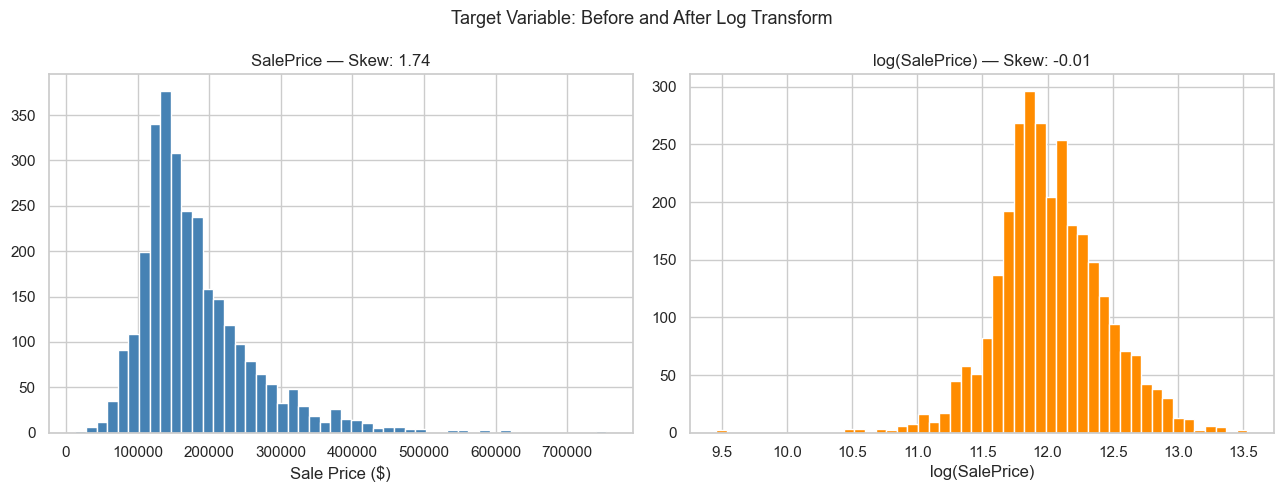

In [39]:
# Apply log1p transformation:

df_feat['SalePrice_Log'] = np.log1p(df_feat['SalePrice'])

# Compare distributions:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df_feat['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title(f'SalePrice — Skew: {df_feat["SalePrice"].skew():.2f}')
axes[0].set_xlabel('Sale Price ($)')

axes[1].hist(df_feat['SalePrice_Log'], bins=50, color='darkorange', edgecolor='white')
axes[1].set_title(f'log(SalePrice) — Skew: {df_feat["SalePrice_Log"].skew():.2f}')
axes[1].set_xlabel('log(SalePrice)')

plt.suptitle('Target Variable: Before and After Log Transform', fontsize=13)
plt.tight_layout()
plt.savefig('C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\03 Feature Engineering\\Report\\log_transform.png', dpi=150)
plt.show()

## Part 4 — Scale Numeric Features

After encoding, numeric features exist on wildly different scales:
- `Lot Area` ranges from 1,300 to 215,245
- `Overall Qual` ranges from 1 to 10
- `House Age` ranges from 0 to 135

Regression models treat all features equally by default.
Without scaling, `Lot Area` would dominate simply because its numbers are large —
not because it is more important.

**StandardScaler** transforms each feature to have mean=0 and std=1.
This levels the playing field.

### G. Scale Features

In [40]:
from sklearn.preprocessing import StandardScaler

# Separate features from target
# Drop the original SalePrice — we will use SalePrice_Log as target
X = df_feat.drop(columns=['SalePrice', 'SalePrice_Log', 'Order', 'PID'],
                 errors='ignore')
y = df_feat['SalePrice_Log']

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Scale
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

print(f"\nScaling complete ✓")
print(f"Mean of scaled features (should be ~0): {X_scaled.mean().mean():.4f}")
print(f"Std of scaled features  (should be ~1): {X_scaled.std().mean():.4f}")

Feature matrix shape: (2927, 238)
Target shape: (2927,)

Scaling complete ✓
Mean of scaled features (should be ~0): 0.0000
Std of scaled features  (should be ~1): 1.0002


In [41]:
#Hard safety net — catch any NaNs before saving:
#(it is possible that some NaNs were introduced during feature engineering or encoding):

print("NaN check before saving:")
print(f"  X NaNs : {X.isnull().sum().sum()}")
print(f"  y NaNs : {y.isnull().sum()}")

if X.isnull().sum().sum() > 0:
    print("\nColumns still containing NaNs:")
    print(X.isnull().sum()[X.isnull().sum() > 0])
    
    # Fill any remaining NaNs with column median
    X = X.fillna(X.median())
    print(f"\nFilled with column median.")
    print(f"NaNs remaining after fill: {X.isnull().sum().sum()}")
else:
    print("Clean — no NaNs found ✓")

NaN check before saving:
  X NaNs : 0
  y NaNs : 0
Clean — no NaNs found ✓


### H. Save the Feature Matrix

In [42]:
import joblib

# Save the feature matrix and target as CSVs
X_scaled.to_csv('C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\00 Data\\Feature Matrix Data\\X_features.csv', index=False)
y.to_csv('C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\00 Data\\Feature Matrix Data\\y_target.csv', index=False)

# Save the scaler so we can inverse-transform predictions later
joblib.dump(scaler, 'C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\00 Data\\Feature Matrix Data\\scaler.pkl')

print(f"X_features.csv saved → shape: {X_scaled.shape}")
print(f"y_target.csv saved   → shape: {y.shape}")
print(f"scaler.pkl saved     → for inverse-transforming predictions")

X_features.csv saved → shape: (2927, 238)
y_target.csv saved   → shape: (2927,)
scaler.pkl saved     → for inverse-transforming predictions


## Feature Engineering Summary

| Step | What was done | Output |
|---|---|---|
| New features | 8 domain-informed columns created | House Age, Total SF, Total Baths… |
| Ordinal encoding | 10 quality columns mapped to 0–5 | Preserves quality ordering |
| One-hot encoding | All remaining categoricals expanded | ~200+ binary columns |
| Log transform | SalePrice → log(SalePrice) | Skew reduced from 1.76 → ~0.12 |
| Scaling | All features standardized (mean=0, std=1) | Model-ready |

**Outputs saved:**
- `X_features.csv` — full feature matrix
- `y_target.csv` — log-transformed target
- `scaler.pkl` — fitted scaler for future use

### Next Step → Phase 5: Regression Modeling
We now have a clean, encoded, scaled feature matrix ready for training.